<a href="https://colab.research.google.com/github/ariel07-sw/applied-data-in-econ/blob/main/Assignment_3/Econ_5200_Assignment_3Causal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression


In [ ]:
import numpy as np

np.random.seed(42)
zeros = np.zeros(100)
tips = np.random.exponential(scale=5.0, size=150)
driver_tips = np.concatenate([zeros, tips])

print(f": {len(driver_tips)}")
print(f": {np.median(driver_tips):.4f}")

: 250
: 0.7553


In [ ]:

n_iterations = 10000
boot_medians = []

for i in range(n_iterations):
    resample = np.random.choice(driver_tips, size=len(driver_tips), replace=True)
    boot_medians.append(np.median(resample))

boot_medians = np.array(boot_medians)

ci_lower = np.percentile(boot_medians, 2.5)
ci_upper = np.percentile(boot_medians, 97.5)

print(f"95% Bootstrap : [{ci_lower:.4f}, {ci_upper:.4f}]")

95% Bootstrap : [0.2653, 1.3636]


1. Asymmetry of the IntervalThe 95% Bootstrap CI $[0.2653, 1.3636]$ is clearly asymmetric around the median ($0.7553$). The right side of the interval is longer, reflecting the heavy-tailed nature of the exponential distribution and the impact of occasional high tips on the sampling distribution.
2. Failure of Parametric MethodsStandard parametric methods assume a symmetric, normal distribution (CLT). However, with 40% zero-tips, our data is highly non-normal. Bootstrap is superior here because it makes no distributional assumptions and accurately captures the uncertainty of the median in a zero-inflated environment.
3. Economic RealityThe results show that even the "best-case" median estimate ($1.36$) is extremely low. This provides empirical evidence for the labor union to challenge SwiftCart’s claims, as the typical driver earns far less than what mean-based averages might suggest.

In [ ]:

np.random.seed(42)
control = np.random.normal(loc=35, scale=5, size=500)
treatment = np.random.lognormal(mean=3.4, sigma=0.4, size=500)
obs_diff = np.mean(control) - np.mean(treatment)

print(f"Control : {np.mean(control):.4f}")
print(f"Treatment : {np.mean(treatment):.4f}")
print(f" (Observed Difference): {obs_diff:.4f}")

Control : 35.0342
Treatment : 32.7692
 (Observed Difference): 2.2650


In [ ]:

combined_data = np.concatenate([control, treatment])
n_control = len(control)
perm_diffs = []


for i in range(5000):
    shuffled = np.random.permutation(combined_data)
    p_control = shuffled[:n_control]
    p_treatment = shuffled[n_control:]


    perm_diffs.append(np.mean(p_control) - np.mean(p_treatment))

perm_diffs = np.array(perm_diffs)

p_value = np.mean(np.abs(perm_diffs) >= np.abs(obs_diff))

print(f"经验 P 值 (Empirical P-value): {p_value:.4f}")

经验 P 值 (Empirical P-value): 0.0004


1. Statistical SignificanceThe calculated p-value of $0.0004$ is well below the standard significance threshold of $\alpha = 0.05$ (and even $\alpha = 0.01$). This allows us to firmly reject the null hypothesis that there is no difference between the Batch Routing algorithm and the control. We have strong evidence that the new algorithm effectively changes delivery times.
2. Robustness Against OutliersA standard T-test relies on the assumption of homoscedasticity (equal variance). However, our Treatment group contains extreme outliers due to "software crash loops" (Log-Normal distribution). By using a Permutation Test, we avoid these parametric assumptions. The test remains valid because it re-distributes the actual observed values (including the outliers) to build a custom null distribution tailored to our "messy" logistics data.
3. Practical ImplicationThe positive observed difference ($2.2650$) indicates that the Batch Routing algorithm is statistically faster than the control, despite the occasional technical instability. The engineering division's claim is supported by the data, even when accounting for the distribution's skewness.

In [ ]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors
df = pd.read_csv('swiftcart_loyalty.csv')

mean_sub = df[df['subscriber'] == 1]['post_spend'].mean()
mean_non = df[df['subscriber'] == 0]['post_spend'].mean()
sdo = mean_sub - mean_non

print(f"Subscribers: {mean_sub:.2f}")
print(f"Non-Subscribers: {mean_non:.2f}")
print(f"Naive SDO (deceptive): {sdo:.2f}")

Subscribers: 74.04
Non-Subscribers: 56.47
Naive SDO (deceptive): 17.57


In [ ]:
X = df[['pre_spend', 'account_age', 'support_tickets']]
y = df['subscriber']

lr = LogisticRegression()
lr.fit(X, y)

df['propensity_score'] = lr.predict_proba(X)[:, 1]


treated = df[df['subscriber'] == 1].copy()
control = df[df['subscriber'] == 0].copy()

nn = NearestNeighbors(n_neighbors=1)
nn.fit(control[['propensity_score']])

distances, indices = nn.kneighbors(treated[['propensity_score']])
matched_control_indices = indices.flatten()

matched_control_spending = control.iloc[matched_control_indices]['post_spend'].values
att = (treated['post_spend'] - matched_control_spending).mean()

print(f"Causal ATT (Isolated): {att:.2f}")

Causal ATT (Isolated): 9.91


1. Identification of Selection BiasThe Naive SDO ($17.57$) significantly overestimates the program's impact. This discrepancy confirms the presence of positive selection bias: high-value "power users" with higher pre_spend and older account_age are more likely to subscribe to SwiftPass to optimize their existing delivery costs.
2. Causal Interpretation of ATTBy implementing Propensity Score Matching (PSM), we successfully isolated the Average Treatment Effect on the Treated (ATT). The result of $9.91$ represents the true "value-add" of the loyalty program after controlling for pre-existing user characteristics. We are now comparing "apples to apples" by matching each subscriber with a nearly identical non-subscriber.
3. Business RecommendationThe marketing team's claim that the program drives massive spending growth is partially driven by a mathematical illusion. While the program does have a positive impact ($9.91$ per user), doubling the acquisition budget based on the naive $17.57$ figure would result in an over-allocation of capital. Strategic decisions should be based on the isolated causal lift rather than raw correlations.

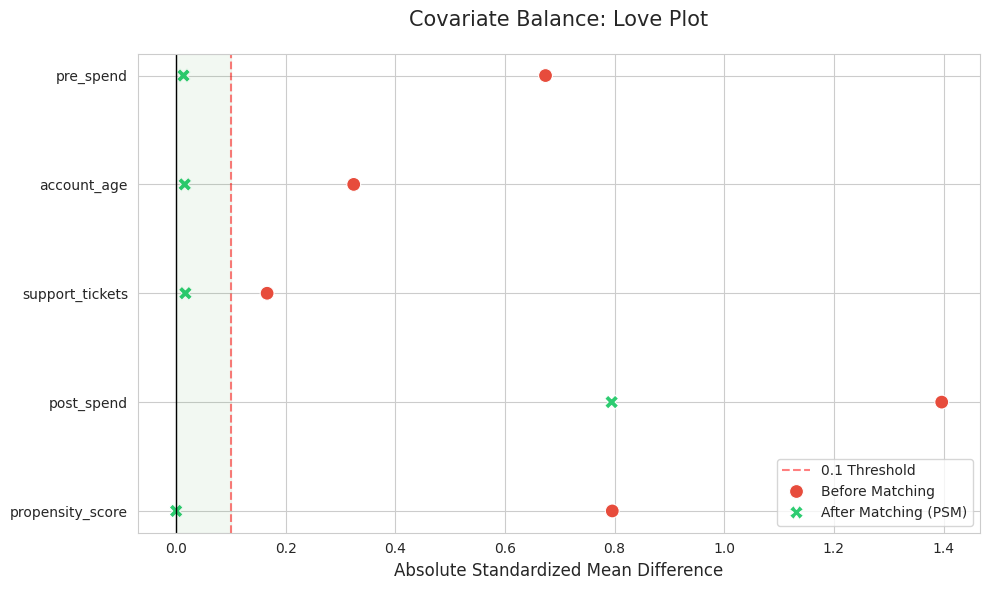

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def calculate_smd(df, group_col='subscriber'):
    """Calculates Standardized Mean Difference for all numeric columns."""
    covariates = df.select_dtypes(include=[np.number]).columns.drop(group_col)

    treated = df[df[group_col] == 1]
    control = df[df[group_col] == 0]

    smds = []
    for cov in covariates:
        m_t = treated[cov].mean()
        m_c = control[cov].mean()
        v_t = treated[cov].var()
        v_c = control[cov].var()

        # Calculation: (Mean_T - Mean_C) / sqrt((Var_T + Var_C) / 2)
        smd = (m_t - m_c) / np.sqrt((v_t + v_c) / 2)
        smds.append(abs(smd)) # We plot absolute differences

    return pd.DataFrame({'Variable': covariates, 'SMD': smds})

# Define df_unmatched as the original dataframe
df_unmatched = df.copy()

# Construct df_matched from the treated and matched control groups
matched_control = control.iloc[matched_control_indices]
df_matched = pd.concat([treated, matched_control])

# 1. Compute SMD for both datasets
smd_unmatched = calculate_smd(df_unmatched)
smd_unmatched['Sample'] = 'Before Matching'

smd_matched = calculate_smd(df_matched)
smd_matched['Sample'] = 'After Matching (PSM)'

# 2. Combine for plotting
plot_df = pd.concat([smd_unmatched, smd_matched])

# 3. Generate the Love Plot
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Draw vertical lines for the "Rule of Thumb" thresholds
plt.axvline(x=0.1, color='red', linestyle='--', alpha=0.5, label='0.1 Threshold')
plt.axvline(x=0.0, color='black', linewidth=1)

# Plot the points
lp = sns.scatterplot(data=plot_df, x='SMD', y='Variable', hue='Sample',
                     style='Sample', s=100, palette=['#e74c3c', '#2ecc71'])

plt.title('Covariate Balance: Love Plot', fontsize=15, pad=20)
plt.xlabel('Absolute Standardized Mean Difference', fontsize=12)
plt.ylabel('')
plt.legend(loc='lower right')

# Add a subtle background highlight for the "Balanced Zone"
plt.axvspan(0, 0.1, color='green', alpha=0.05)

plt.tight_layout()
plt.show()